Design and implement a Convolutional Neural Network (CNN) for image classification using the Tomato or Soybean disease dataset.

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

In [ ]:
!kaggle datasets download -d zunorain/tomato-dataset-v2 -p /content

Dataset URL: https://www.kaggle.com/datasets/zunorain/tomato-dataset-v2
License(s): apache-2.0
100% 460M/460M [00:25<00:00, 18.6MB/s]



In [ ]:
!ls -lh /content/*.zip

-rw-r--r-- 1 root root 460M Jun  5  2025 /content/tomato-dataset-v2.zip


In [ ]:
!unzip -t /content/tomato-dataset-v2.zip | tail -5

    testing: augmented_dataset/Tomato_healthy/img_996.jpg   OK
    testing: augmented_dataset/Tomato_healthy/img_997.jpg   OK
    testing: augmented_dataset/Tomato_healthy/img_998.jpg   OK
    testing: augmented_dataset/Tomato_healthy/img_999.jpg   OK
No errors detected in compressed data of /content/tomato-dataset-v2.zip.


In [ ]:
import zipfile
import os

zip_path = "/content/tomato-dataset-v2.zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/tomato_dataset"):
    print(root)
    print("Folders:", dirs[:15])

    if root.count(os.sep) > 4:
        dirs[:] = []

/content/tomato_dataset
Folders: ['augmented_dataset']
/content/tomato_dataset/augmented_dataset
Folders: ['Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Septoria_leaf_spot', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato__Tomato_mosaic_virus']
/content/tomato_dataset/augmented_dataset/Tomato__Tomato_YellowLeaf__Curl_Virus
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato_Bacterial_spot
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato_Late_blight
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato_Leaf_Mold
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato_Spider_mites_Two_spotted_spider_mite
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato_Septoria_leaf_spot
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato__Target_Spot
Folders: []
/content/tomato_dataset/augmented_dataset/Tomato_E

In [ ]:
import os

base_path = "/content/tomato_dataset"

print("Contents of dataset:")
for item in os.listdir(base_path):
    print(" -", item)

Contents of dataset:
 - augmented_dataset


In [ ]:
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        for file in files[:5]:
            print(f"{indent}    {file}")

tomato_dataset/
    augmented_dataset/
        Tomato__Tomato_YellowLeaf__Curl_Virus/
        Tomato_Bacterial_spot/
        Tomato_Late_blight/
        Tomato_Leaf_Mold/
        Tomato_Spider_mites_Two_spotted_spider_mite/
        Tomato_Septoria_leaf_spot/
        Tomato__Target_Spot/
        Tomato_Early_blight/
        Tomato_healthy/
        Tomato__Tomato_mosaic_virus/


In [ ]:
train_dir = None
test_dir = None

for root, dirs, files in os.walk(base_path):
    folder_names = [d.lower() for d in dirs]

    if "train" in folder_names:
        train_dir = os.path.join(root, dirs[folder_names.index("train")])

    if "test" in folder_names:
        test_dir = os.path.join(root, dirs[folder_names.index("test")])

print("Train directory:", train_dir)
print("Test directory:", test_dir)

Train directory: None
Test directory: None


In [ ]:
import os

base_path = "/content/tomato_dataset"

print("Contents of /content/tomato_dataset:")
print(os.listdir(base_path))

Contents of /content/tomato_dataset:
['augmented_dataset']


In [ ]:
print("\nFull folder structure:\n")

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = "    " * level

    print(indent + os.path.basename(root) + "/")

    # Show first 3 files if present
    for file in files[:3]:
        print(indent + "    " + file)

    if level >= 3:
        dirs[:] = []


Full folder structure:

tomato_dataset/
    augmented_dataset/
        Tomato__Tomato_YellowLeaf__Curl_Virus/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_Bacterial_spot/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_Late_blight/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_Leaf_Mold/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_Spider_mites_Two_spotted_spider_mite/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_Septoria_leaf_spot/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato__Target_Spot/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_Early_blight/
            img_601.jpg
            img_210.jpg
            img_1363.jpg
        Tomato_healthy/
            img_601.jpg
            img_210.jpg
  

In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("\nFolders containing images:\n")

for root, dirs, files in os.walk(base_path):

    image_count = sum(
        1 for f in files
        if f.lower().endswith(image_extensions)
    )

    if image_count > 0:
        print(root, "→", image_count, "images")


Folders containing images:

/content/tomato_dataset/augmented_dataset/Tomato__Tomato_YellowLeaf__Curl_Virus → 3208 images
/content/tomato_dataset/augmented_dataset/Tomato_Bacterial_spot → 3164 images
/content/tomato_dataset/augmented_dataset/Tomato_Late_blight → 3106 images
/content/tomato_dataset/augmented_dataset/Tomato_Leaf_Mold → 2975 images
/content/tomato_dataset/augmented_dataset/Tomato_Spider_mites_Two_spotted_spider_mite → 3104 images
/content/tomato_dataset/augmented_dataset/Tomato_Septoria_leaf_spot → 3112 images
/content/tomato_dataset/augmented_dataset/Tomato__Target_Spot → 3064 images
/content/tomato_dataset/augmented_dataset/Tomato_Early_blight → 2963 images
/content/tomato_dataset/augmented_dataset/Tomato_healthy → 3072 images
/content/tomato_dataset/augmented_dataset/Tomato__Tomato_mosaic_virus → 2841 images


In [ ]:
import os

dataset_dir = "/content/tomato_dataset/augmented_dataset"

print("Dataset path:", dataset_dir)
print("\nClasses:")

classes = sorted([
    folder
    for folder in os.listdir(dataset_dir)
    if os.path.isdir(os.path.join(dataset_dir, folder))
])

for i, class_name in enumerate(classes):
    print(i, ":", class_name)

print("\nTotal classes:", len(classes))

Dataset path: /content/tomato_dataset/augmented_dataset

Classes:
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy

Total classes: 10


In [ ]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

total_images = 0

print("Images per class:\n")

for class_name in classes:

    class_path = os.path.join(dataset_dir, class_name)

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    print(f"{class_name}: {count}")

    total_images += count

print("\nTotal images:", total_images)

Images per class:

Tomato_Bacterial_spot: 3164
Tomato_Early_blight: 2963
Tomato_Late_blight: 3106
Tomato_Leaf_Mold: 2975
Tomato_Septoria_leaf_spot: 3112
Tomato_Spider_mites_Two_spotted_spider_mite: 3104
Tomato__Target_Spot: 3064
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Tomato__Tomato_mosaic_virus: 2841
Tomato_healthy: 3072

Total images: 30609


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 30609 files belonging to 10 classes.
Using 24488 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 30609 files belonging to 10 classes.
Using 6121 files for validation.


In [ ]:
class_names = train_ds.class_names

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, ":", name)

Number of classes: 10
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy


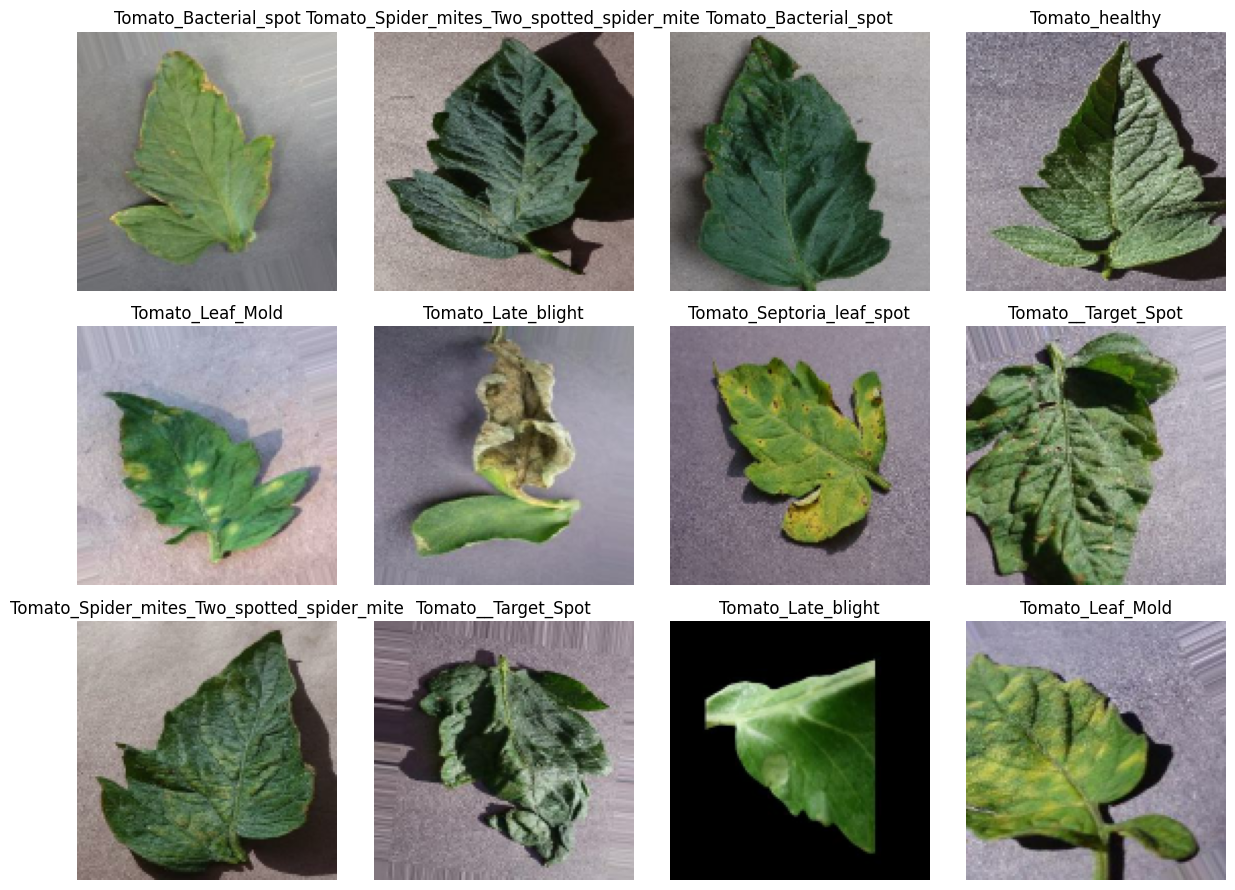

In [ ]:
plt.figure(figsize=(12, 9))

for images, labels in train_ds.take(1):

    for i in range(min(12, len(images))):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
num_classes = len(class_names)

model = models.Sequential([

    # Input
    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels from 0-255 to 0-1
    layers.Rescaling(1./255),

    # Convolution Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convolution Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    # Flatten
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    layers.Dropout(0.5),

    # Output
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.4780 - loss: 1.4783 - val_accuracy: 0.9456 - val_loss: 0.2315
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 36s 30ms/step - accuracy: 0.6869 - loss: 0.9019 - val_accuracy: 0.9616 - val_loss: 0.1450
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.7533 - loss: 0.7129 - val_accuracy: 0.9562 - val_loss: 0.1601
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.7900 - loss: 0.5994 - val_accuracy: 0.9778 - val_loss: 0.1027
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.8137 - loss: 0.5369 - val_accuracy: 0.9843 - val_loss: 0.0873
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8352 - loss: 0.4665 - val_accuracy: 0.9861 - val_loss: 0.0751
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.8474 - loss: 0.4352 - val_accuracy: 0.9891 - val_loss: 0.0621
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8569 - loss: 0.4058 - 

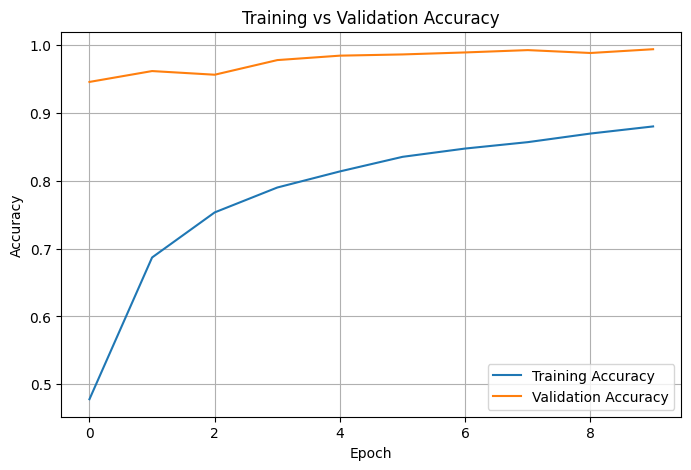

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

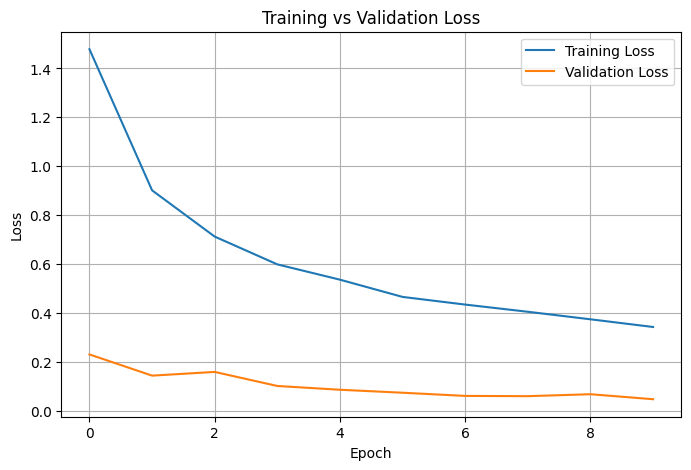

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("Validation Accuracy (%):", round(accuracy * 100, 2))

192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9938 - loss: 0.0486
Validation Loss: 0.04859260842204094
Validation Accuracy: 0.9937918782234192
Validation Accuracy (%): 99.38


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

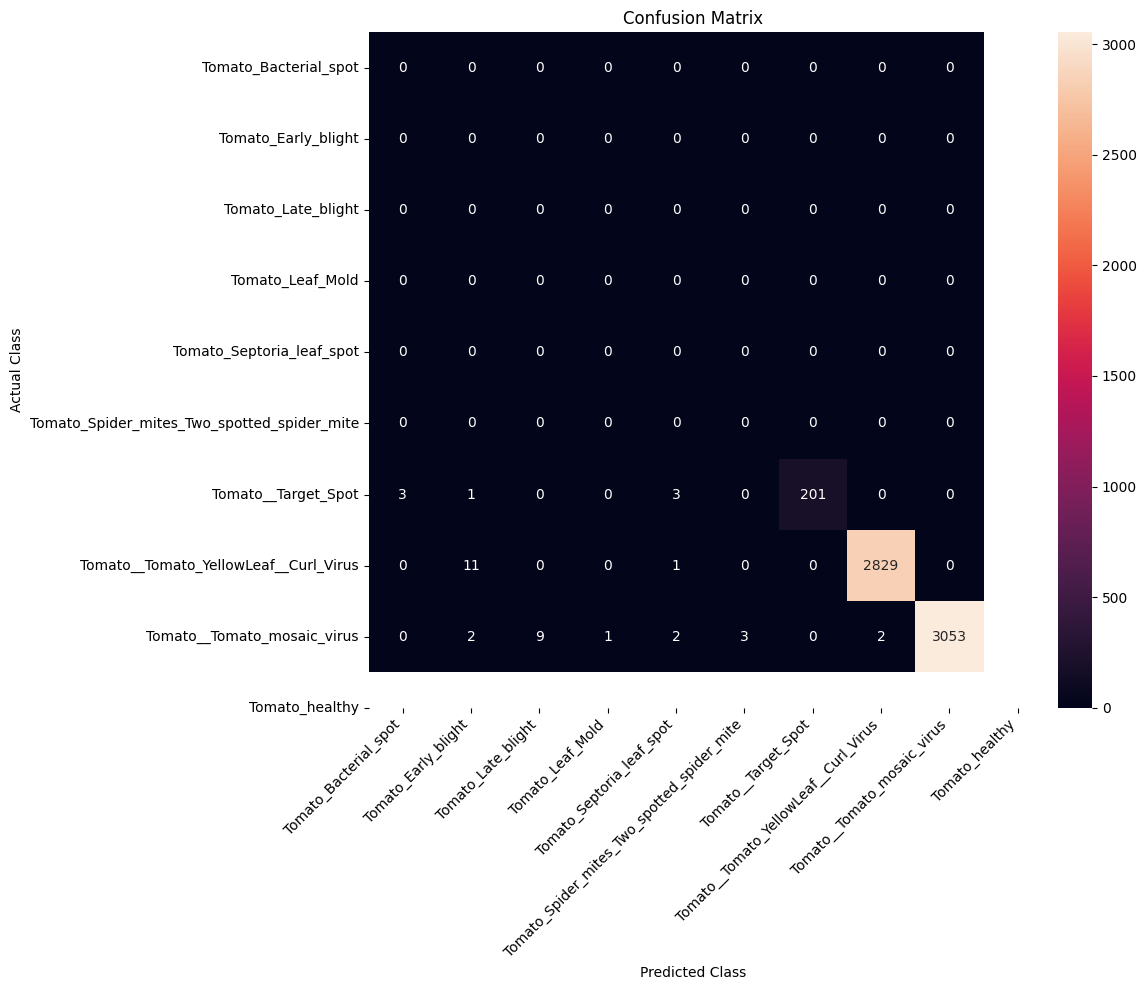

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    )
)

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.00      0.00      0.00         0
                        Tomato_Early_blight       0.00      0.00      0.00         0
                         Tomato_Late_blight       0.00      0.00      0.00         0
                           Tomato_Leaf_Mold       0.00      0.00      0.00         0
                  Tomato_Septoria_leaf_spot       0.00      0.00      0.00         0
Tomato_Spider_mites_Two_spotted_spider_mite       0.00      0.00      0.00         0
                        Tomato__Target_Spot       0.00      0.00      0.00         0
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.97      0.98       208
                Tomato__Tomato_mosaic_virus       1.00      1.00      1.00      2841
                             Tomato_healthy       1.00      0.99      1.00      3072

                                   accuracy                    

In [ ]:
model.save("/content/tomato_disease_cnn.keras")

print("Model saved successfully!")

Model saved successfully!
